# Enviroment Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# !!! ACTION REQUIRED !!! - update paths for your project structure

DRIVE_PATH = '/content/drive/MyDrive/DP'

DATA_DIR = f'{DRIVE_PATH}/02_processed_data'
RES_DIR = f'{DRIVE_PATH}/05_prediction_results'
VIS_DIR = f'{DRIVE_PATH}/03_visualizations/Experiments/BASELINE'

# Processed Data

In [4]:
DATASETS = {
    'Boralesgamuwa': {
        'file': 'boralasgamuwa_processed.csv',
        'label': 'Boralesgamuwa UC (Sri Lanka)',
        'code': 'bo',
        'number': '1'
    },
    'Dehiwala': {
        'file': 'dehiwala_processed.csv',
        'label': 'Dehiwala MC (Sri Lanka)',
        'code': 'de',
        'number': '2'
    },
    'Homagama': {
        'file': 'homagama_processed.csv',
        'label': 'Homagama PS (Sri Lanka)',
        'code': 'ho',
        'number': '3'
    },
    'Moratuwa': {
        'file': 'moratuwa_processed.csv',
        'label': 'Moratuwa MC (Sri Lanka)',
        'code': 'mo',
        'number': '4'
    },
    'Austin': {
        'file': 'austin_processed.csv',
        'label': 'Austin TX (USA)',
        'code': 'au',
        'number': '5'
    },
    'Ballarat': {
        'file': 'ballarat_processed.csv',
        'label': 'Ballarat (Australia)',
        'code': 'ba',
        'number': '6'
    }
}

# Model Definition - Baseline

In [5]:
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error — robust to zero values."""
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator > 0
    if mask.sum() == 0:
        return float('nan')
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100


def run_baseline_prediction(df, dataset_name, dataset_code, dataset_number, split_days=90, n_splits=3, VIS_DIR='.'):
    """
    Baseline model: predict tomorrow = rolling 7-day mean of previous days.
    Uses rolling_7_mean which is already computed in EDA (with shift(1), no leakage).

    This serves as the lower bound — any ML model should beat this.
    Plots are generated ONLY for the best split (lowest sMAPE).
    """
    print(f"\n{'='*100}")
    print(f"BASELINE (7-DAY ROLLING MEAN) — {dataset_name}")
    print(f"{'='*100}")

    df = df.sort_values('date').reset_index(drop=True)
    df_valid = df[df['total_tonnes'].notna() & df['rolling_7_mean'].notna()].reset_index(drop=True)
    print(f"Total rows: {len(df)}, Valid rows: {len(df_valid)}")


    # ============================================================
    # ROLLING-ORIGIN VALIDATION
    # ============================================================
    split_results = []

    if len(df_valid) < split_days * n_splits + 100:
        print(f"WARNING: Reducing to 2 splits due to data size.")
        n_splits = 2

    print(f"\nRolling-origin validation: {n_splits} splits of {split_days} days each")

    best_smape = float('inf')
    best_split_data = None

    for split_idx in range(n_splits):
        offset = (n_splits - 1 - split_idx) * split_days

        if offset == 0:
            test = df_valid.iloc[-split_days:]
            test_start_iloc = len(df_valid) - split_days
        else:
            test = df_valid.iloc[-(offset + split_days):-offset]
            test_start_iloc = len(df_valid) - (offset + split_days)

        y_true = test['total_tonnes'].values
        y_pred = test['rolling_7_mean'].values

        # dropping NaNs
        mask = ~(np.isnan(y_true) | np.isnan(y_pred))
        y_true_clean = y_true[mask]
        y_pred_clean = y_pred[mask]
        test_clean = test[mask]

        if len(y_true_clean) == 0:
            print(f"  Split {split_idx+1}: No valid data, skipping.")
            continue

        mae = mean_absolute_error(y_true_clean, y_pred_clean)
        rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
        smape_val = smape(y_true_clean, y_pred_clean)

        split_results.append({'mae': mae, 'rmse': rmse, 'smape': smape_val})

        print(f"  Split {split_idx+1}/{n_splits}: MAE={mae:.2f}t | RMSE={rmse:.2f}t | sMAPE={smape_val:.2f}%")

        # track the best split
        if smape_val < best_smape:
            best_smape = smape_val

            context_start_iloc = max(0, test_start_iloc - 30)
            context = df_valid.iloc[context_start_iloc:test_start_iloc]

            best_split_data = {
                'split_idx': split_idx + 1,
                'test': test_clean,
                'context': context,
                'y_true': y_true_clean,
                'y_pred': y_pred_clean,
                'mae': mae,
                'rmse': rmse,
                'smape': smape_val
            }


    # ============================================================
    # AVERAGE METRICS
    # ============================================================
    avg_mae = np.mean([r['mae'] for r in split_results])
    avg_rmse = np.mean([r['rmse'] for r in split_results])
    avg_smape = np.mean([r['smape'] for r in split_results])

    print(f"\n--- AVERAGE ACROSS {len(split_results)} SPLITS ---")
    print(f"MAE:   {avg_mae:.2f} tonnes")
    print(f"RMSE:  {avg_rmse:.2f} tonnes")
    print(f"sMAPE: {avg_smape:.2f}%")
    print(f"Best split was Split {best_split_data['split_idx']} (sMAPE: {best_split_data['smape']:.2f}%)")


    # ============================================================
    # PLOT — BEST SPLIT ONLY
    # ============================================================
    test_plot = best_split_data['test']
    context = best_split_data['context']
    y_true_plot = best_split_data['y_true']
    y_pred_plot = best_split_data['y_pred']


    # --- Plot: Actual vs Baseline ---
    fig, ax = plt.subplots(figsize=(16, 6))

    ax.plot(context['date'], context['total_tonnes'], color='steelblue',
            linewidth=1, label='Historical Data (last 30 days)')
    ax.plot(test_plot['date'], y_true_plot, color='steelblue',
            linewidth=1.5, label='Actual (Test)')
    ax.plot(test_plot['date'], y_pred_plot, color='red',
            linewidth=1.5, linestyle='--', label='Baseline (7d Rolling Mean)')
    ax.axvline(x=test_plot['date'].iloc[0], color='gray', linestyle=':',
               alpha=0.7, label='Train/Test Split')

    ax.set_title(f"Baseline Forecast vs Actual — {dataset_name} (Best Split: #{best_split_data['split_idx']})",
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.set_xlabel('Date')
    ax.legend(fontsize=10)

    ax.text(0.02, 0.95,
            f"Best Split Metrics:\nMAE: {best_split_data['mae']:.2f}t\nRMSE: {best_split_data['rmse']:.2f}t\nsMAPE: {best_split_data['smape']:.1f}%",
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.savefig(os.path.join(VIS_DIR, f'0{dataset_number}1_baseline_forecast_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'dataset': dataset_name,
        'model': 'Baseline (7d mean)',
        'mae': round(avg_mae, 2),
        'rmse': round(avg_rmse, 2),
        'smape': round(avg_smape, 2),
        'n_splits': len(split_results),
        'split_days': split_days,
        'split_details': split_results
    }

# Model Prediction - SARIMA


BASELINE (7-DAY ROLLING MEAN) — Boralesgamuwa UC (Sri Lanka)
Total rows: 2527, Valid rows: 2382

Rolling-origin validation: 3 splits of 90 days each
  Split 1/3: MAE=8.83t | RMSE=10.88t | sMAPE=32.63%
  Split 2/3: MAE=6.53t | RMSE=8.36t | sMAPE=27.94%
  Split 3/3: MAE=7.72t | RMSE=9.66t | sMAPE=29.85%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   7.69 tonnes
RMSE:  9.63 tonnes
sMAPE: 30.14%
Best split was Split 2 (sMAPE: 27.94%)


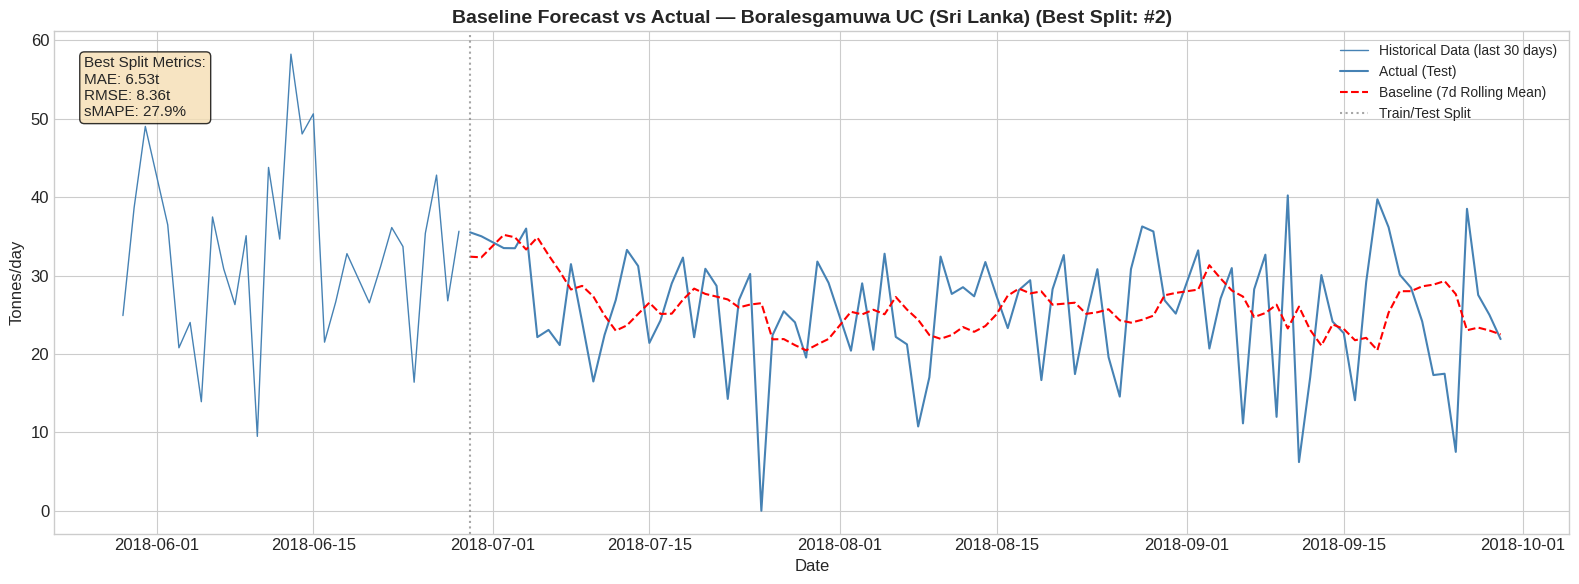


BASELINE (7-DAY ROLLING MEAN) — Dehiwala MC (Sri Lanka)
Total rows: 1431, Valid rows: 1402

Rolling-origin validation: 3 splits of 90 days each
  Split 1/3: MAE=32.95t | RMSE=42.68t | sMAPE=22.76%
  Split 2/3: MAE=33.53t | RMSE=43.07t | sMAPE=29.71%
  Split 3/3: MAE=32.71t | RMSE=42.59t | sMAPE=25.76%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   33.06 tonnes
RMSE:  42.78 tonnes
sMAPE: 26.08%
Best split was Split 1 (sMAPE: 22.76%)


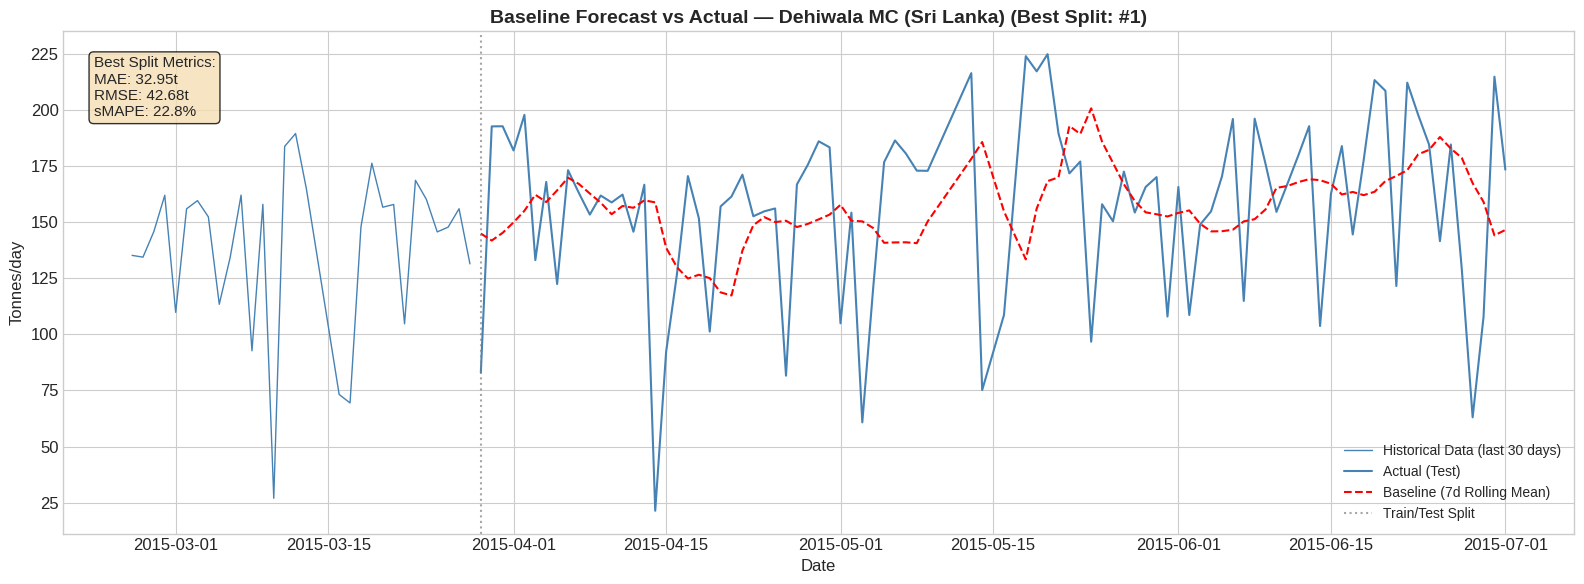


BASELINE (7-DAY ROLLING MEAN) — Homagama PS (Sri Lanka)
Total rows: 2526, Valid rows: 2031

Rolling-origin validation: 3 splits of 90 days each
  Split 1/3: MAE=11.87t | RMSE=15.14t | sMAPE=34.37%
  Split 2/3: MAE=9.73t | RMSE=12.83t | sMAPE=31.48%
  Split 3/3: MAE=12.05t | RMSE=15.41t | sMAPE=33.95%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   11.21 tonnes
RMSE:  14.46 tonnes
sMAPE: 33.27%
Best split was Split 2 (sMAPE: 31.48%)


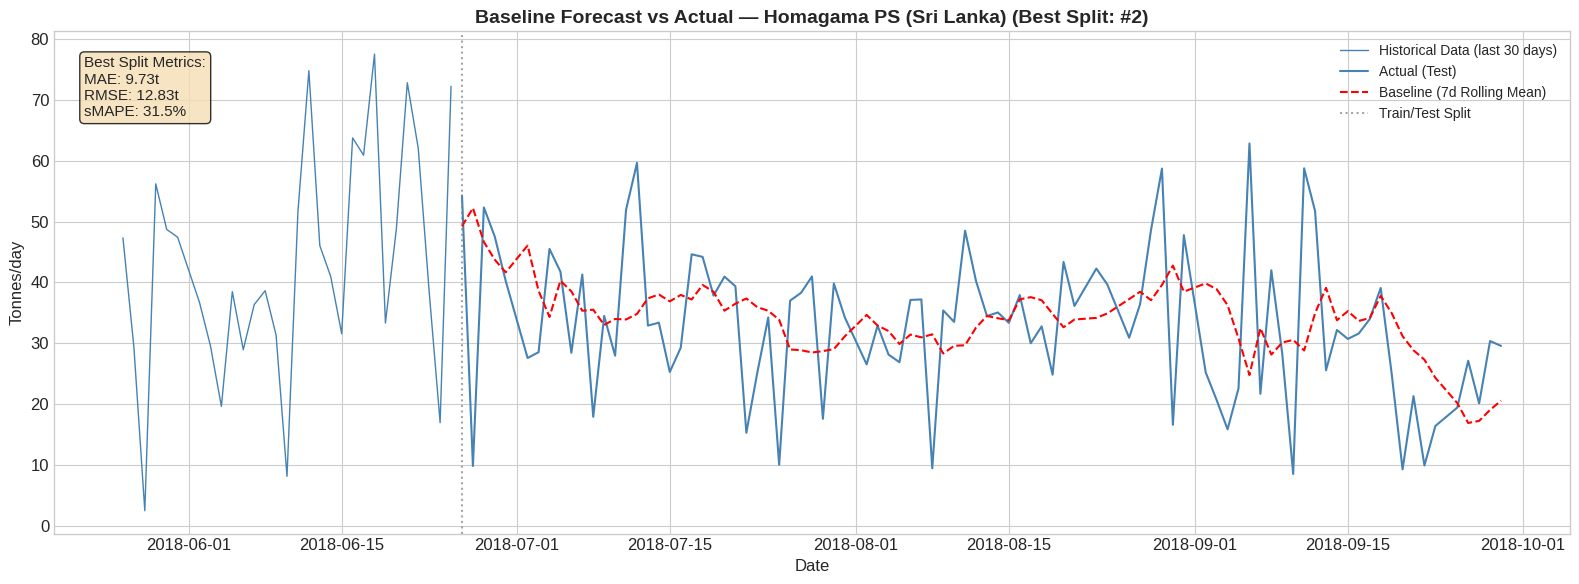


BASELINE (7-DAY ROLLING MEAN) — Moratuwa MC (Sri Lanka)
Total rows: 1411, Valid rows: 1274

Rolling-origin validation: 3 splits of 90 days each
  Split 1/3: MAE=17.66t | RMSE=24.43t | sMAPE=26.16%
  Split 2/3: MAE=17.32t | RMSE=22.36t | sMAPE=24.78%
  Split 3/3: MAE=17.82t | RMSE=22.67t | sMAPE=27.49%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   17.60 tonnes
RMSE:  23.15 tonnes
sMAPE: 26.15%
Best split was Split 2 (sMAPE: 24.78%)


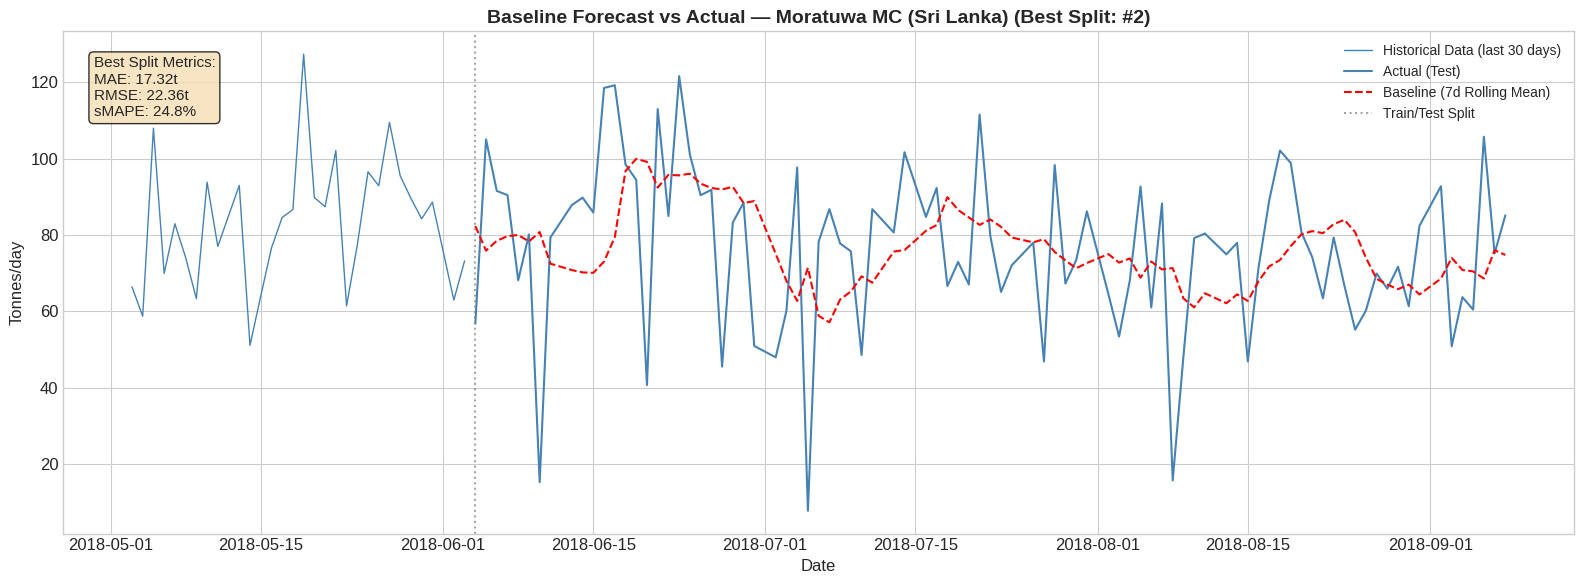


BASELINE (7-DAY ROLLING MEAN) — Austin TX (USA)
Total rows: 5813, Valid rows: 5803

Rolling-origin validation: 3 splits of 90 days each
  Split 1/3: MAE=859.53t | RMSE=1016.81t | sMAPE=76.28%
  Split 2/3: MAE=779.33t | RMSE=905.62t | sMAPE=79.29%
  Split 3/3: MAE=840.39t | RMSE=951.91t | sMAPE=77.59%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   826.42 tonnes
RMSE:  958.11 tonnes
sMAPE: 77.72%
Best split was Split 1 (sMAPE: 76.28%)


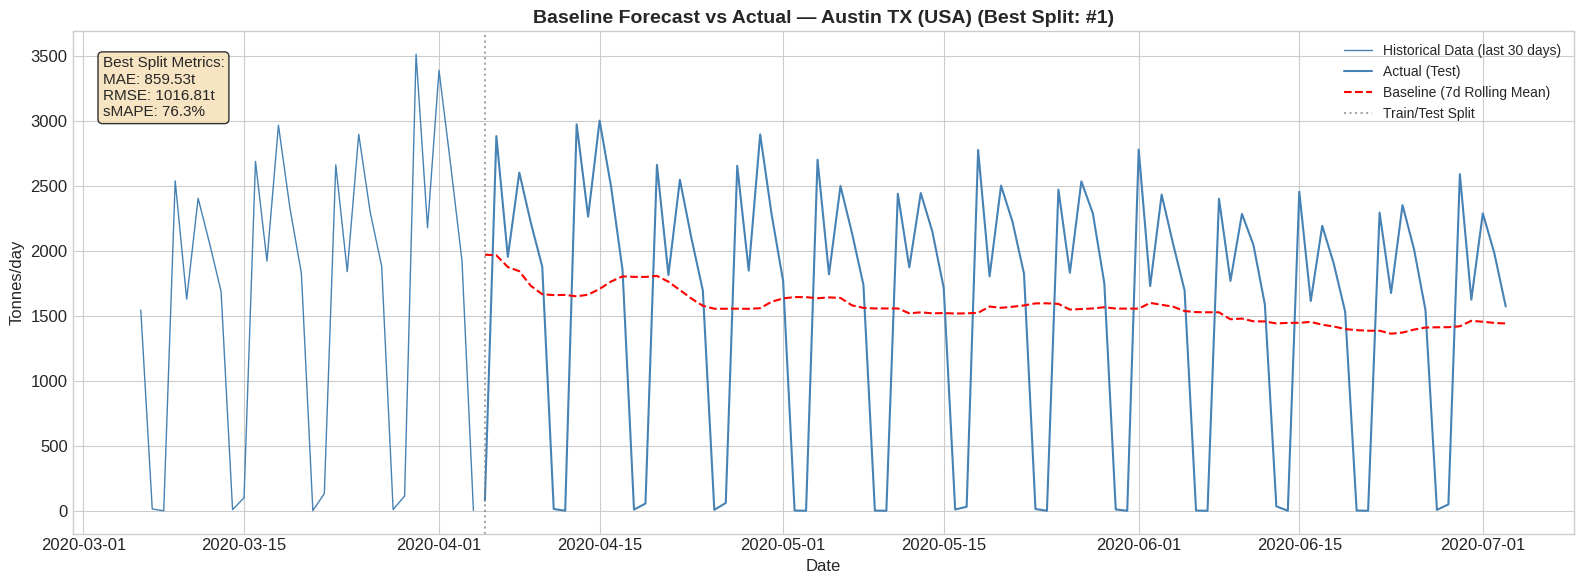


BASELINE (7-DAY ROLLING MEAN) — Ballarat (Australia)
Total rows: 4717, Valid rows: 4703

Rolling-origin validation: 3 splits of 90 days each
  Split 1/3: MAE=32.11t | RMSE=37.54t | sMAPE=80.65%
  Split 2/3: MAE=34.62t | RMSE=40.68t | sMAPE=81.35%
  Split 3/3: MAE=35.69t | RMSE=42.09t | sMAPE=78.33%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   34.14 tonnes
RMSE:  40.10 tonnes
sMAPE: 80.11%
Best split was Split 3 (sMAPE: 78.33%)


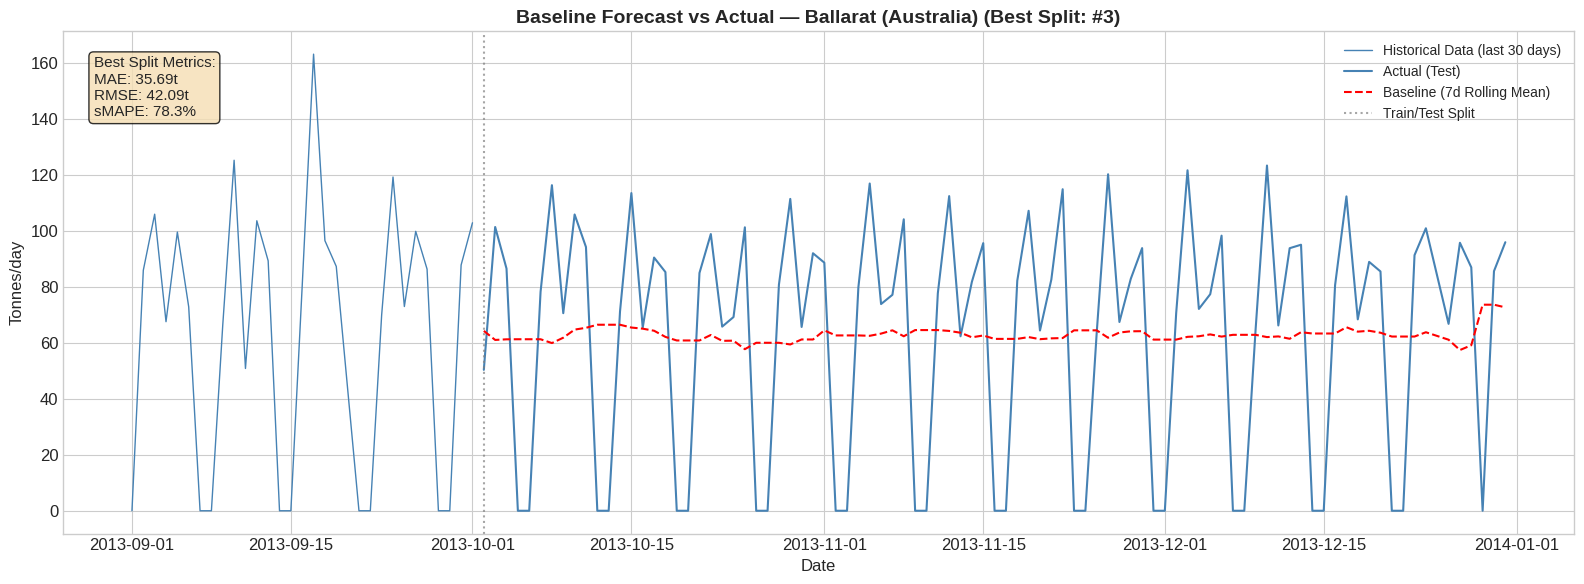

In [6]:
all_results = []

for name, config in DATASETS.items():
    filepath = os.path.join(DATA_DIR, config['file'])

    try:
        df = pd.read_csv(filepath)
        df['date'] = pd.to_datetime(df['date'])

        result = run_baseline_prediction(
            df=df,
            dataset_name=config['label'],
            dataset_code=config['code'],
            dataset_number=config['number'],
            split_days=90,
            n_splits=3
        )
        all_results.append(result)

    except Exception as e:
        print(f"\n{'='*100}")
        print(f"ERROR processing {name}: {e}")
        print(f"{'='*100}")
        import traceback
        traceback.print_exc()

# Prediction Summary

In [7]:
print("\n" + "=" * 100)
print("BASELINE RESULTS SUMMARY — ALL DATASETS")
print("=" * 100)

results_df = pd.DataFrame(all_results)

print(f"\nModel: Baseline (7-day rolling mean)")
print(f"Validation: Rolling-origin with {all_results[0]['n_splits']} splits of {all_results[0]['split_days']} days")
print(f"Metrics are AVERAGED across splits.")

print(f"\n{'Dataset':<30s} | {'MAE (t)':>8s} | {'RMSE (t)':>9s} | {'sMAPE (%)':>9s}")
print("-" * 65)
for _, row in results_df.iterrows():
    print(f"{row['dataset']:<30s} | {row['mae']:>8.2f} | {row['rmse']:>9.2f} | {row['smape']:>8.2f}%")

print("-" * 65)
print(f"{'AVERAGE':<30s} | {results_df['mae'].mean():>8.2f} | {results_df['rmse'].mean():>9.2f} | {results_df['smape'].mean():>8.2f}%")

# Per-split detail
print(f"\n--- Per-split details ---")
for _, row in results_df.iterrows():
    print(f"\n{row['dataset']}:")
    for j, s in enumerate(row['split_details']):
        print(f"  Split {j+1}: MAE={s['mae']:.2f}t, RMSE={s['rmse']:.2f}t, sMAPE={s['smape']:.2f}%")

# save results
results_df.to_csv(os.path.join(RES_DIR, 'baseline_results.csv'), index=False)
print(f"\nResults saved to: {RES_DIR}/baseline_results.csv")


BASELINE RESULTS SUMMARY — ALL DATASETS

Model: Baseline (7-day rolling mean)
Validation: Rolling-origin with 3 splits of 90 days
Metrics are AVERAGED across splits.

Dataset                        |  MAE (t) |  RMSE (t) | sMAPE (%)
-----------------------------------------------------------------
Boralesgamuwa UC (Sri Lanka)   |     7.69 |      9.63 |    30.14%
Dehiwala MC (Sri Lanka)        |    33.06 |     42.78 |    26.08%
Homagama PS (Sri Lanka)        |    11.21 |     14.46 |    33.27%
Moratuwa MC (Sri Lanka)        |    17.60 |     23.15 |    26.15%
Austin TX (USA)                |   826.42 |    958.11 |    77.72%
Ballarat (Australia)           |    34.14 |     40.10 |    80.11%
-----------------------------------------------------------------
AVERAGE                        |   155.02 |    181.37 |    45.58%

--- Per-split details ---

Boralesgamuwa UC (Sri Lanka):
  Split 1: MAE=8.83t, RMSE=10.88t, sMAPE=32.63%
  Split 2: MAE=6.53t, RMSE=8.36t, sMAPE=27.94%
  Split 3: MAE=7.72

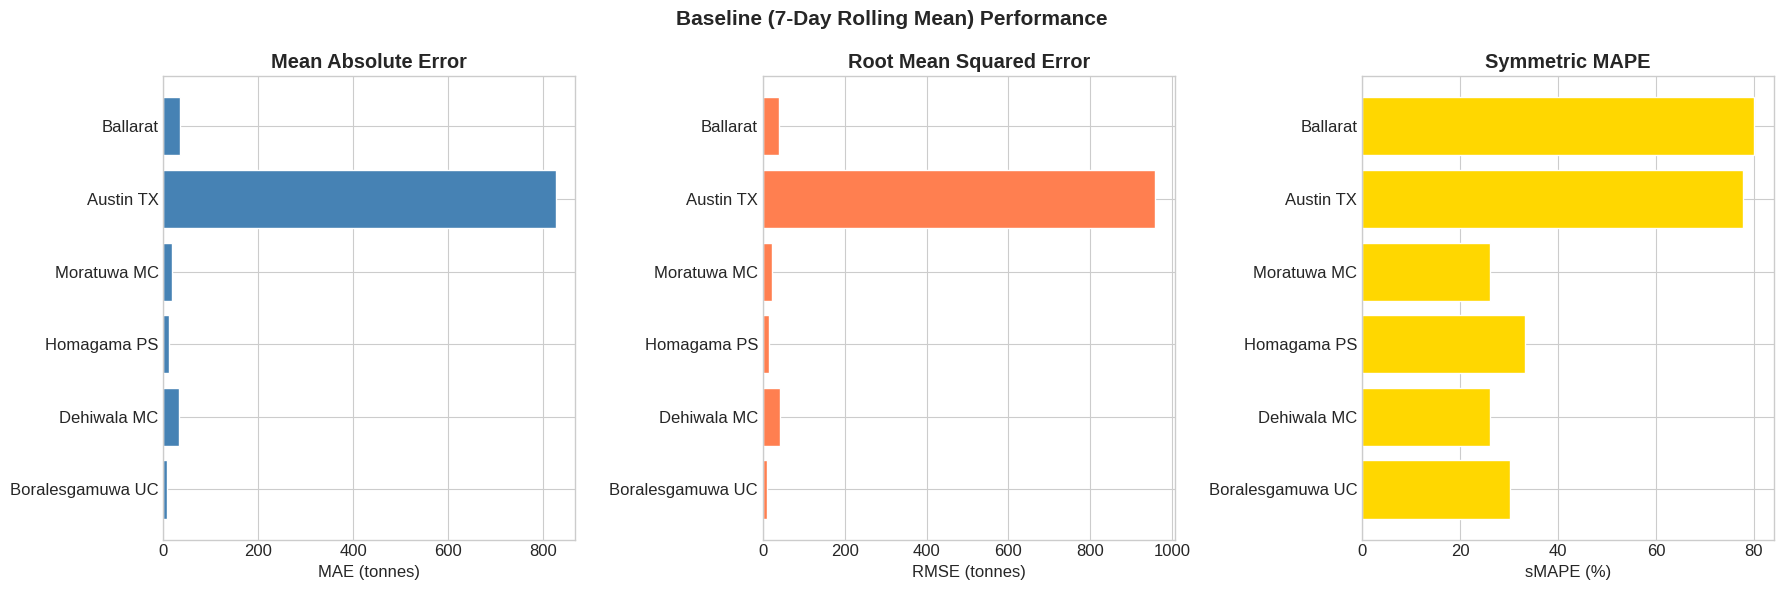

In [8]:
# --- Plot 101: SARIMA Performance ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

short_names = [r['dataset'].split('(')[0].strip() for r in all_results]

axes[0].barh(short_names, results_df['mae'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('MAE (tonnes)')
axes[0].set_title('Mean Absolute Error', fontweight='bold')

axes[1].barh(short_names, results_df['rmse'], color='coral', edgecolor='white')
axes[1].set_xlabel('RMSE (tonnes)')
axes[1].set_title('Root Mean Squared Error', fontweight='bold')

axes[2].barh(short_names, results_df['smape'], color='gold', edgecolor='white')
axes[2].set_xlabel('sMAPE (%)')
axes[2].set_title('Symmetric MAPE', fontweight='bold')

plt.suptitle('Baseline (7-Day Rolling Mean) Performance', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '001_sarima_comparison_all.png'), dpi=150, bbox_inches='tight')
plt.show()